In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DATA_PATH = r"data/hdfc/HDFCBANK.csv"
COMPANY_NAME = "HDFC Bank"

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-01,213.700867,238.012497,238.600006,236.262497,237.750000,3544940
1,2015-01-02,216.675018,241.324997,242.324997,237.600006,237.600006,5900384
2,2015-01-05,214.845612,239.287506,242.637497,238.774994,242.500000,4796000
3,2015-01-06,211.501114,235.562500,239.137497,234.387497,238.500000,8219680
4,2015-01-07,212.118362,236.250000,237.837494,234.062500,234.925003,5746112


General

In [7]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

Shape: (2898, 7)

Columns:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Data types:
Date         datetime64[us]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object

Date range:
2015-01-01 00:00:00 to 2026-09-21 00:00:00


Trend

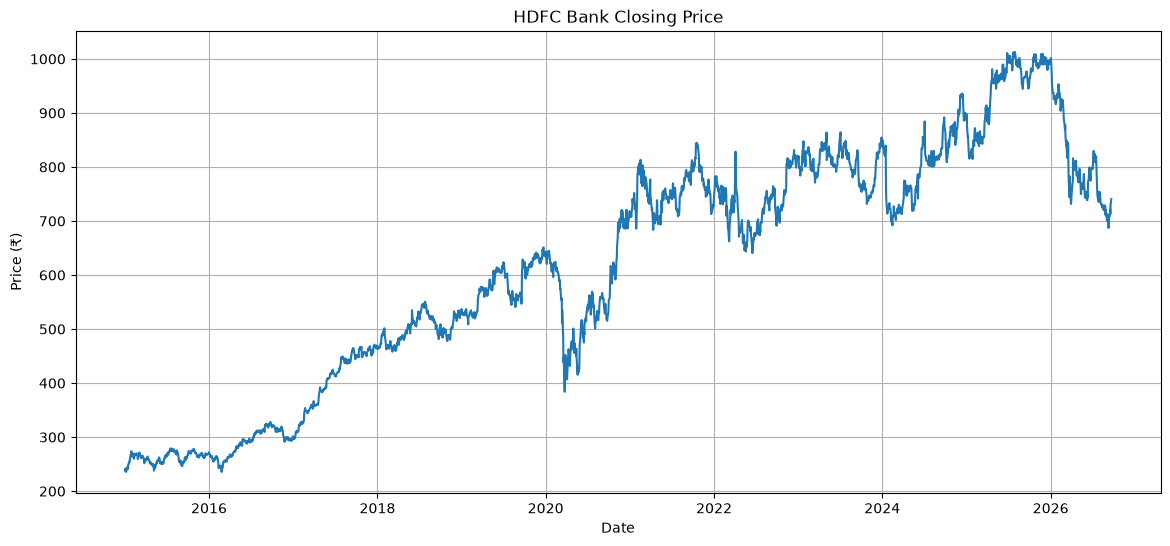

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"])
plt.title(f"{COMPANY_NAME} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

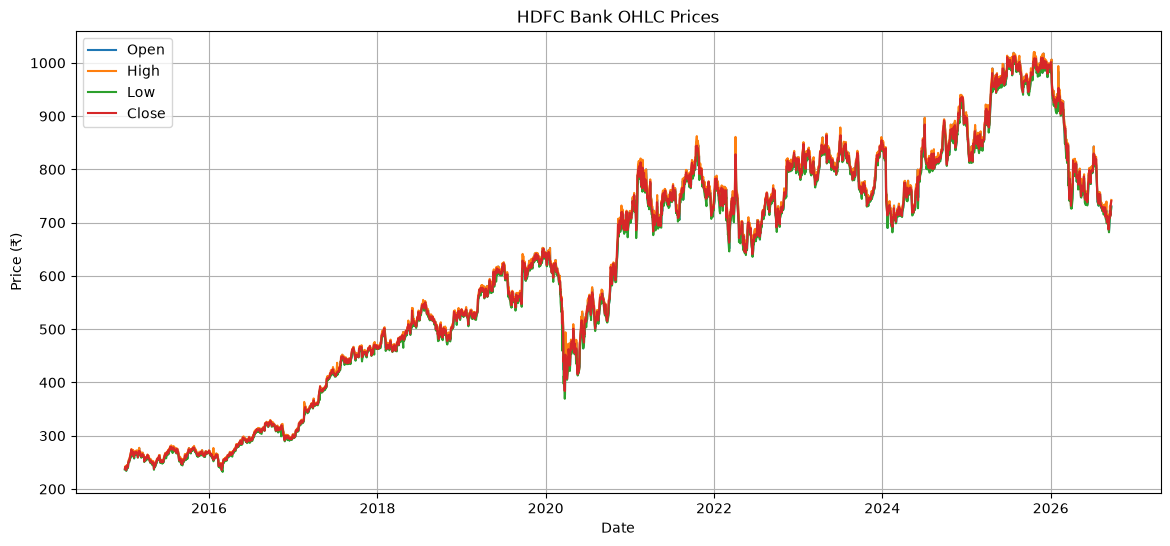

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Open"], label="Open")
plt.plot(df["Date"], df["High"], label="High")
plt.plot(df["Date"], df["Low"], label="Low")
plt.plot(df["Date"], df["Close"], label="Close")

plt.title(f"{COMPANY_NAME} OHLC Prices")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

Volume

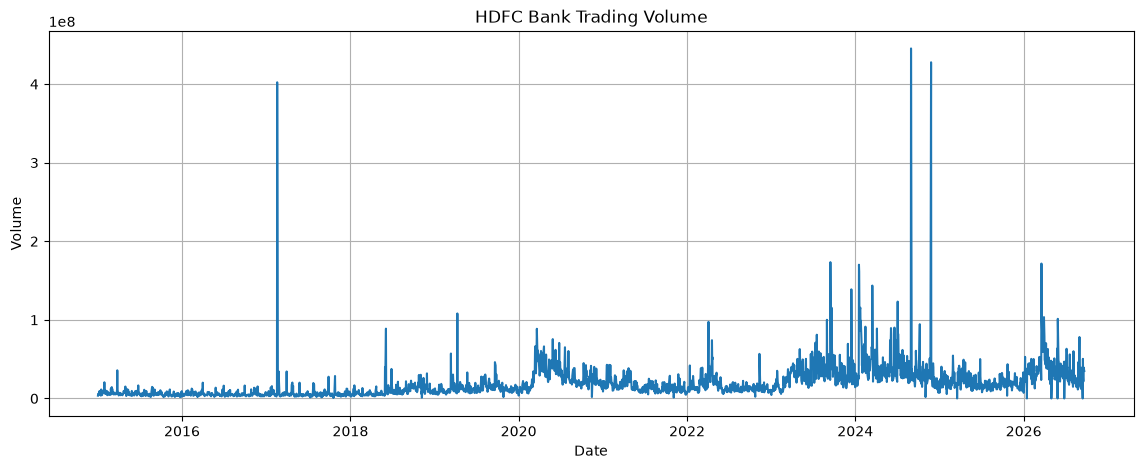

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Volume"])

plt.title(f"{COMPANY_NAME} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

In [11]:
df["Volume"].describe()

count    2.898000e+03
mean     1.894180e+07
std      2.131356e+07
min      0.000000e+00
25%      7.051636e+06
50%      1.338185e+07
75%      2.482429e+07
max      4.453421e+08
Name: Volume, dtype: float64

Returns

In [12]:
df["Return"] = df["Close"].pct_change()

df[["Date", "Close", "Return"]].head(10)

,Date,Close,Return
0,2015-01-01,238.012497,NaN
1,2015-01-02,241.324997,0.013917
2,2015-01-05,239.287506,-0.008443
3,2015-01-06,235.562500,-0.015567
4,2015-01-07,236.250000,0.002919
5,2015-01-08,241.212494,0.021005
6,2015-01-09,243.912506,0.011194
7,2015-01-12,241.762497,-0.008815
8,2015-01-13,240.837494,-0.003826
9,2015-01-14,240.975006,0.000571


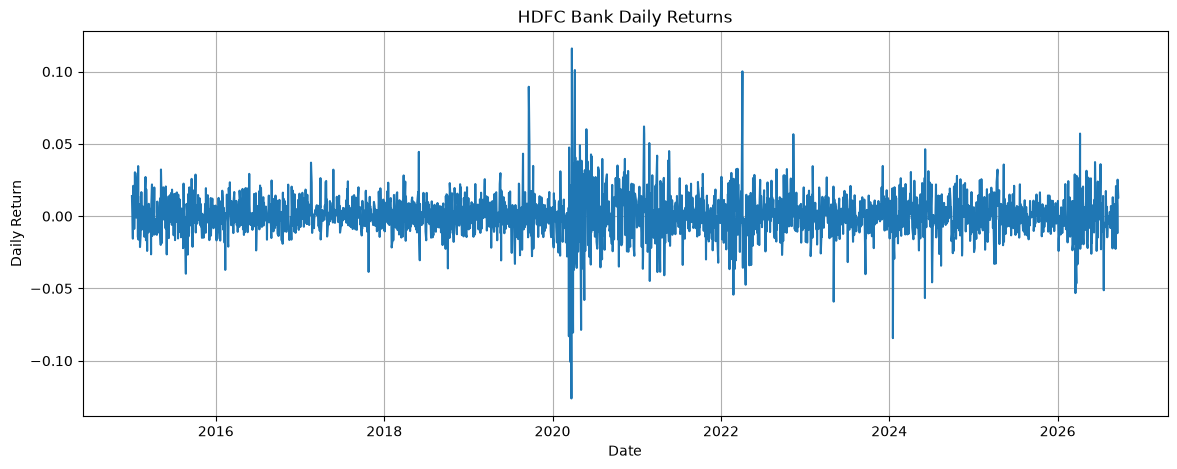

In [14]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Return"])

plt.title(f"{COMPANY_NAME} Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [15]:
df["Return"].describe()

count    2897.000000
mean        0.000491
std         0.014049
min        -0.126069
25%        -0.006482
50%         0.000361
75%         0.007173
max         0.115996
Name: Return, dtype: float64

Annual Volatility

In [16]:
annual_volatility = df["Return"].std() * np.sqrt(252)

print(f"Annualized volatility: {annual_volatility:.2%}")

Annualized volatility: 22.30%


Simple Moving Averages

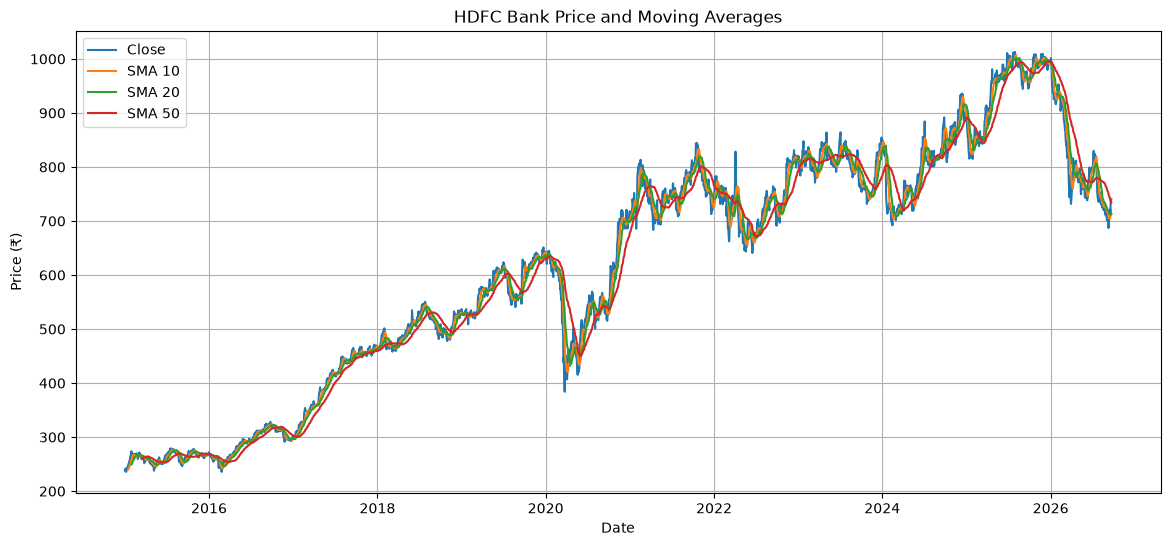

In [17]:
df["SMA_10"] = df["Close"].rolling(10).mean()
df["SMA_20"] = df["Close"].rolling(20).mean()
df["SMA_50"] = df["Close"].rolling(50).mean()

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["SMA_10"], label="SMA 10")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
plt.plot(df["Date"], df["SMA_50"], label="SMA 50")

plt.title(f"{COMPANY_NAME} Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

Exponential Moving Averages

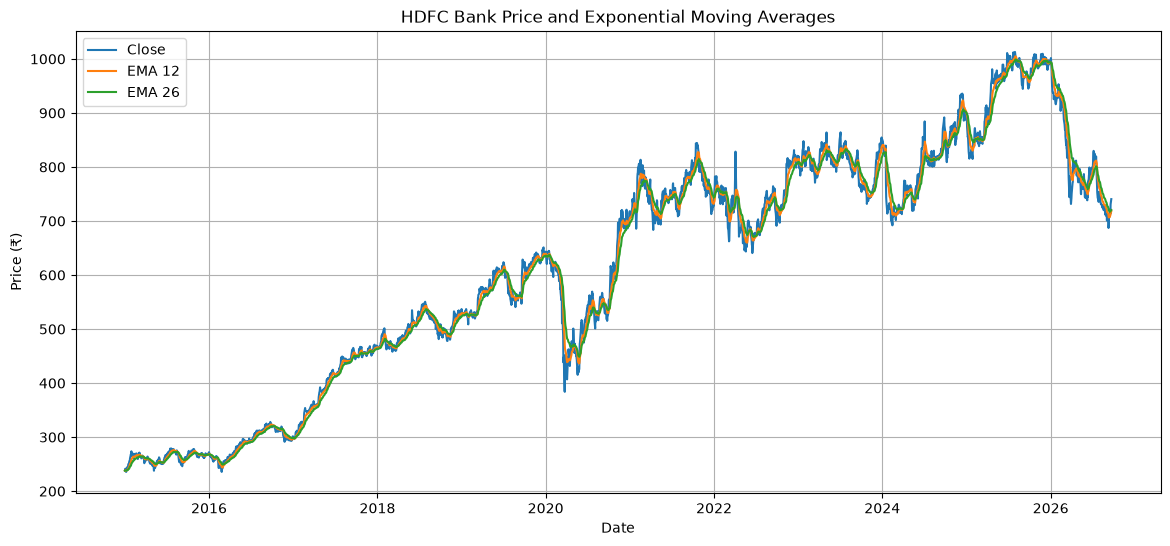

In [18]:
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["EMA_12"], label="EMA 12")
plt.plot(df["Date"], df["EMA_26"], label="EMA 26")

plt.title(f"{COMPANY_NAME} Price and Exponential Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

Twenty Day Rolling Volitality

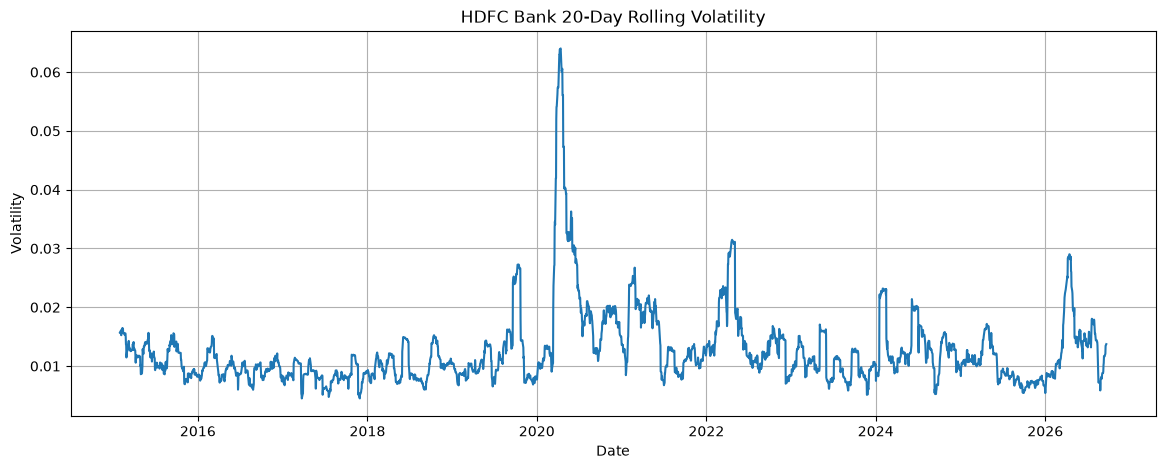

In [19]:
df["Volatility_20"] = df["Return"].rolling(20).std()

plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Volatility_20"])

plt.title(f"{COMPANY_NAME} 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

Correlation

In [24]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return",
    "SMA_10",
    "SMA_20",
    "SMA_50",
    "EMA_12",
    "EMA_26",
    "Volatility_20",
]

df[features].corr()

,Open,High,Low,Close,Volume,Return,SMA_10,SMA_20,SMA_50,EMA_12,EMA_26,Volatility_20
Open,1.000000,0.999690,0.999692,0.999392,0.351312,-0.029516,0.997881,0.995340,0.988037,0.998179,0.995660,0.026940
High,0.999690,1.000000,0.999579,0.999747,0.356286,-0.015589,0.997886,0.995451,0.988401,0.998221,0.995812,0.033483
Low,0.999692,0.999579,1.000000,0.999715,0.345934,-0.016849,0.997683,0.995041,0.987562,0.997996,0.995356,0.018442
Close,0.999392,0.999747,0.999715,1.000000,0.350385,-0.002998,0.997630,0.995110,0.987870,0.997986,0.995459,0.025690
Volume,0.351312,0.356286,0.345934,0.350385,1.000000,0.001108,0.353392,0.357329,0.366830,0.355881,0.362437,0.297279
Return,-0.029516,-0.015589,-0.016849,-0.002998,0.001108,1.000000,-0.037501,-0.034736,-0.035467,-0.035236,-0.037236,0.018088
SMA_10,0.997881,0.997886,0.997683,0.997630,0.353392,-0.037501,1.000000,0.998684,0.992042,0.999853,0.998540,0.027233
SMA_20,0.995340,0.995451,0.995041,0.995110,0.357329,-0.034736,0.998684,1.000000,0.995542,0.999104,0.999665,0.034350
SMA_50,0.988037,0.988401,0.987562,0.987870,0.366830,-0.035467,0.992042,0.995542,1.000000,0.993254,0.997200,0.066999
EMA_12,0.998179,0.998221,0.997996,0.997986,0.355881,-0.035236,0.999853,0.999104,0.993254,1.000000,0.999070,0.029655


<Axes: >

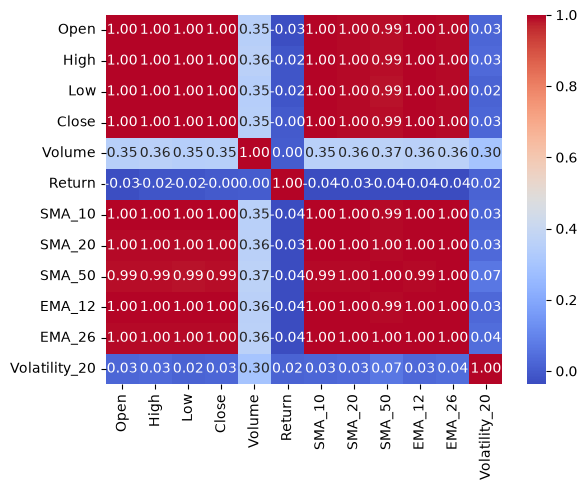

In [26]:
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

In [27]:
df.tail()

,Date,Adj Close,Close,High,Low,Open,Volume,Return,SMA_10,SMA_20,SMA_50,EMA_12,EMA_26,Volatility_20
2893,2026-09-15,716.549988,716.549988,730.750000,715.049988,722.400024,50387632,0.011719,704.699994,712.744998,741.484000,708.576967,717.828524,0.011875
2894,2026-09-16,721.500000,721.500000,725.400024,710.849976,714.900024,27476943,0.006908,706.769995,712.819998,739.708000,710.565126,718.100485,0.011948
2895,2026-09-17,713.000000,713.000000,719.400024,713.000000,717.500000,21543303,-0.011781,707.404993,712.217499,737.617001,710.939722,717.722672,0.012119
2896,2026-09-18,731.000000,731.000000,733.799988,715.250000,715.250000,39400710,0.025245,709.294995,712.419998,735.738000,714.025918,718.706177,0.013437
2897,2026-09-21,740.500000,740.500000,742.650024,729.049988,731.000000,34928484,0.012996,712.294995,712.994998,734.189000,718.098854,720.320535,0.013724


In [28]:
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,2898.0,6.173638e+02,2.187416e+02,234.925003,4.571937e+02,6.519250e+02,7.935000e+02,1.018850e+03
High,2898.0,6.227516e+02,2.204762e+02,237.837494,4.621562e+02,6.596375e+02,7.998750e+02,1.020500e+03
Low,2898.0,6.118974e+02,2.172580e+02,232.000000,4.535375e+02,6.460875e+02,7.867750e+02,1.008500e+03
Close,2898.0,6.173479e+02,2.187834e+02,235.562500,4.561156e+02,6.531375e+02,7.932875e+02,1.012900e+03
Volume,2898.0,1.894180e+07,2.131356e+07,0.000000,7.051636e+06,1.338185e+07,2.482429e+07,4.453421e+08
Return,2897.0,4.906436e-04,1.404874e-02,-0.126069,-6.481645e-03,3.613305e-04,7.173355e-03,1.159958e-01
SMA_10,2889.0,6.177754e+02,2.182736e+02,239.913750,4.570450e+02,6.576050e+02,7.919150e+02,1.006850e+03
SMA_20,2879.0,6.182650e+02,2.177835e+02,246.386876,4.569303e+02,6.668112e+02,7.920300e+02,1.001265e+03
SMA_50,2849.0,6.195810e+02,2.164293e+02,252.514001,4.608922e+02,6.646675e+02,7.896740e+02,9.957550e+02
EMA_12,2898.0,6.164368e+02,2.188387e+02,237.871590,4.558963e+02,6.600177e+02,7.912647e+02,1.004847e+03


The correlation analysis indicates strong multicollinearity among OHLC and moving-average-based features. However, these features capture different aspects of price and trend information. To maintain a compact observation space while retaining market, trend, momentum, and volatility information, the final RL state will use Close, Volume, Return, SMA-20, SMA-50, EMA-12, EMA-26, and 20-day volatility. Feature scaling and relative transformations will be performed using the training data during model development.